In [21]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [22]:
ticker="META"

df = yf.download(ticker, period='6mo')
df
prices = df['Close']
#si quiero que no cuente el dato de hoy 
prices = prices[:-1]
prices.tail()

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_76812/2619754829.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='6mo')
[*********************100%***********************]  1 of 1 completed


Ticker,META
Date,
2026-09-16,672.779053
2026-09-17,681.771973
2026-09-18,665.225037
2026-09-21,741.250000
2026-09-22,736.599976


<module 'matplotlib.pyplot' from '/opt/anaconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

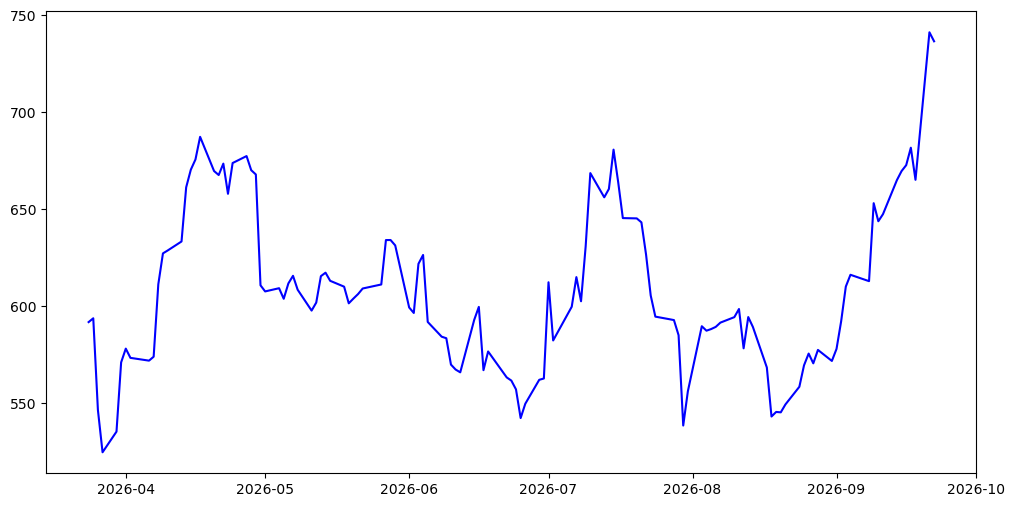

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices.values, label='META Closing Prices', color='blue')
plt

## Opción Europea

In [25]:
S0 = df["Close"].iloc[0].item()
ST = df["Close"].iloc[-1].item()
K = S0

S0, ST, K

(591.9038696289062, 744.0999755859375, 591.9038696289062)

In [26]:
payoff_call_EU = max(ST - K, 0)

payoff_put_EU = max(K - ST, 0)

payoff_call_EU, payoff_put_EU

(152.19610595703125, 0)

## Opción Asiática

In [27]:
promedio = df["Close"].mean().item()

promedio

609.6598640501968

In [28]:
payoff_call_AS = max(promedio - K, 0)

payoff_put_AS = max(K - promedio, 0)

payoff_call_AS, payoff_put_AS

(17.755994421290552, 0)

## Opción Lookback(Flotante)

In [32]:
maximo = df["Close"].max().item()
minimo = df["Close"].min().item()

payoff_call_LB = ST - minimo
payoff_put_LB = maximo - ST

payoff_call_LB, payoff_put_LB

(219.281005859375, 0.0)